In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv('../data/merged/NEW_clean_data.csv') # z notatnika NEW_cleaning

In [4]:
data.columns

Index(['tmdbId', 'title', 'release_date', 'runtime', 'original_language',
       'vote_average', 'vote_count', 'origin_countries', 'spoken_languages',
       'year', 'keywords', 'genres', 'director_id', 'director_name',
       'director_gender', 'writer_id', 'writer_name', 'writer_gender',
       'actor4_id', 'actor4_name', 'actor4_gender', 'actor2_id', 'actor2_name',
       'actor2_gender', 'actor1_id', 'actor1_name', 'actor1_gender',
       'actor5_id', 'actor5_name', 'actor5_gender', 'actor3_id', 'actor3_name',
       'actor3_gender', 'budget_adjusted', 'revenue_adjusted', 'quarter',
       'main_genre', 'main_country', 'director_movie_count',
       'writer_movie_count', 'actors_avg_movie_count', 'writer_avg_revenue',
       'writer_max_revenue', 'director_avg_revenue', 'director_max_revenue',
       'actor1_avg_revenue', 'actor1_max_revenue', 'actor2_avg_revenue',
       'actor2_max_revenue', 'actor3_avg_revenue', 'actor3_max_revenue',
       'actor4_avg_revenue', 'actor4_max_reve

# Wybór tylko tych kolumn, które będą brane pod uwage w modelach
Wyrzucenie takich, które niosą redundantne informacje albo są niepotrzebne albo już zamieniliśmy je innymi kolumnami w trakcie czyszczenia

In [5]:
data = data[['runtime', 'original_language',
       'vote_average', 'vote_count', 'year', 'keywords', 'genres',
       'budget_adjusted', 'revenue_adjusted', 'quarter',
       'main_genre', 'main_country', 'director_movie_count',
       'writer_movie_count', 'actors_avg_movie_count', 'writer_avg_revenue',
       'writer_max_revenue', 'director_avg_revenue', 'director_max_revenue',
       'actors_avg_revenue', 'actors_max_revenue',
       'female_actors', 'top_people_number', 'top_people']]

In [6]:
# Kraje: Tylko te które mają ponad 200 filmów
# Języki: Tylko podział na angielski i resztę

data['original_language'] = np.where(data['original_language'] == 'en', 'en', 'other')
country_counts = data['main_country'].value_counts()
countries_to_replace = country_counts[country_counts < 200].index
data['main_country'] = data['main_country'].replace(countries_to_replace, 'Other')

print(data['original_language'].value_counts())
print(data['main_country'].value_counts())

original_language
en       7233
other    1953
Name: count, dtype: int64
main_country
USA              5048
Other            1928
UnitedKingdom     658
France            501
India             430
Canada            348
Germany           273
Name: count, dtype: int64


# Kodowanie 0-1

In [7]:
genres_encoded = data['genres'].str.get_dummies(sep=', ')
data = pd.concat([data, genres_encoded], axis=1)

In [8]:
language_encoded = pd.get_dummies(data['original_language'], prefix='lang', dtype=int)
data = pd.concat([data, language_encoded], axis=1)

In [9]:
country_encoded = pd.get_dummies(data['main_country'], dtype=int)
data = pd.concat([data, country_encoded], axis=1)

In [10]:
mapping = {
    "based on novel or book": "based on book",
    "adapted from:book": "based on book",
    "based on a book": "based on book",

    "good action": "action",

    "love story": "love",
    "romance": "love",

    "hilarious": "funny",
    "parody": "funny",
    "silly fun": "funny",
    "amused": "funny",
    "fun movie": "funny",

    "teen movie": "teen",
    "coming of age": "teen",
    "teenager": "teen",
    "high school": "teen",

    "fight scenes": "violence",
    "martial arts": "violence",
    "gunfight": "violence",
    "brutality": "violence",

    "based on a true story": "true story",
    "based on true story": "true story",

    "chick flick": "girlie movie",
}

kw = (
    data['keywords']
    .str.split(',')
    .explode()
    .str.strip()
    .to_frame(name='keyword')
)

kw['keyword'] = kw['keyword'].map(mapping).fillna(kw['keyword'])

kw_counts = kw['keyword'].value_counts()
kw_counts

keyword
based on book         860
original              860
action                746
violence              694
funny                 599
                     ... 
bracknell               1
ironman                 1
personal injury         1
swansea                 1
sports documentary      1
Name: count, Length: 9693, dtype: int64

In [11]:
wybrane_keywords = kw_counts[kw_counts > 120].index
wybrane_keywords

Index(['based on book', 'original', 'action', 'violence', 'funny',
       'true story', 'teen', 'comedy', 'love', 'girlie movie', 'horror',
       'drama', 'family', 'sequel', 'murder', 'remake', 'woman director',
       'animation', 'mentor', 'romantic', 'predictable', 'supernatural',
       'independent film', 'sports', 'weird', 'friendship', 'chase',
       'relationships', 'visually appealing', 'suspense', 'romantic comedy',
       'new york city', 'serial killer', 'revenge', 'musical', 'high school',
       'small town', 'superhero', 'alien', 'biography', 'fantasy world'],
      dtype='object', name='keyword')

In [12]:
for keyword in wybrane_keywords:
    col_name = f"kw_{keyword.replace(' ', '_')}"
    data[col_name] = data['keywords'].str.contains(keyword, case=False, na=False).astype(int)

In [13]:
data.drop(columns=['keywords', 'main_country', 'original_language', 'genres', 'main_genre', 'top_people'], inplace=True)
data.columns

Index(['runtime', 'vote_average', 'vote_count', 'year', 'budget_adjusted',
       'revenue_adjusted', 'quarter', 'director_movie_count',
       'writer_movie_count', 'actors_avg_movie_count', 'writer_avg_revenue',
       'writer_max_revenue', 'director_avg_revenue', 'director_max_revenue',
       'actors_avg_revenue', 'actors_max_revenue', 'female_actors',
       'top_people_number', 'action', 'adventure', 'animation', 'children',
       'comedy', 'crime', 'documentary', 'drama', 'family', 'fantasy',
       'film-noir', 'history', 'horror', 'imax', 'musical', 'mystery',
       'romance', 'sci-fi', 'thriller', 'tvmovie', 'war', 'western', 'lang_en',
       'lang_other', 'Canada', 'France', 'Germany', 'India', 'Other', 'USA',
       'UnitedKingdom', 'kw_based_on_book', 'kw_original', 'kw_action',
       'kw_violence', 'kw_funny', 'kw_true_story', 'kw_teen', 'kw_comedy',
       'kw_love', 'kw_girlie_movie', 'kw_horror', 'kw_drama', 'kw_family',
       'kw_sequel', 'kw_murder', 'kw_remake'

In [14]:
# Niby powinniśmy to usunąć bo nie powinniśmy mieć info o tym z przyszłośći
data = data.drop(columns=['vote_average', 'vote_count'])

In [15]:
data

,runtime,year,budget_adjusted,revenue_adjusted,quarter,director_movie_count,writer_movie_count,actors_avg_movie_count,writer_avg_revenue,writer_max_revenue,...,kw_new_york_city,kw_serial_killer,kw_revenge,kw_musical,kw_high_school,kw_small_town,kw_superhero,kw_alien,kw_biography,kw_fantasy_world
0,98,1995,8.449948e+06,8.993604e+06,4,15,13,8.2,2.384469e+08,5.964630e+08,...,0,0,0,0,0,0,0,0,0,0
1,109,1993,4.678756e+07,2.704085e+07,4,9,9,3.6,7.272651e+07,1.714053e+08,...,0,0,0,0,0,0,0,0,0,0
2,100,2003,1.644709e+08,1.645296e+09,2,9,7,12.4,1.081580e+09,1.645296e+09,...,0,0,0,0,0,0,0,0,0,0
3,142,1994,1.194795e+08,1.471527e+09,2,20,13,21.8,3.225962e+08,1.471527e+09,...,0,0,0,0,0,0,0,0,0,0
4,122,1999,2.898646e+07,6.885186e+08,3,9,1,9.0,6.885186e+08,6.885186e+08,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9181,137,2025,2.000000e+07,4.227859e+08,3,1,1,1.0,4.227859e+08,4.227859e+08,...,0,0,0,0,0,0,0,0,0,0
9182,224,2025,6.500000e+07,3.500000e+06,4,6,1,2.6,3.500000e+06,3.500000e+06,...,0,0,1,0,0,0,0,0,0,0
9183,88,2023,1.056583e+04,5.599891e+04,2,1,1,1.0,5.599891e+04,5.599891e+04,...,0,0,1,0,0,0,0,0,0,0
9184,127,2025,1.600000e+06,1.472934e+06,4,3,1,1.2,1.472934e+06,1.472934e+06,...,0,0,0,0,0,0,0,0,0,0


In [15]:
data.to_csv("../data/merged/data_model.csv", index = False)

# MODELE 
### UWAGA optymalizowanie hiperparametrów się długo liczy

In [16]:
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [17]:
data.shape

(9186, 88)

In [17]:
# Usunięcie outlierów
q_low = data['revenue_adjusted'].quantile(0.01)
q_high = data['revenue_adjusted'].quantile(0.99)
data_filtered = data[(data['revenue_adjusted'] >= q_low) & (data['revenue_adjusted'] <= q_high)].copy()
data_filtered.shape

(9002, 88)

In [18]:
# Przygotowanie zbiorów - do zastanowienia czy logarytmować revenue i budget

X = data_filtered.drop(columns=['revenue_adjusted'])
y = data_filtered['revenue_adjusted']

# tu podzieliłam 80% - 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

## Random Forest

In [ ]:
# OPTUNA
# do optymalizacji hiperparametrów (bez tego były fatalne modele)
# Można pewnie potem to puścić na więcej trials i 5-krotną walidacje to może jeszcze znajdzie lepsze

# W innych modelach zalecam to samo żeby używać tej optuny


def objective(trial):
    param_grid = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
    }

    model = RandomForestRegressor(**param_grid, random_state=123, n_jobs=-1)

    # 3-krotna cross-walidacja - minimalizacja MAPE
    scores = cross_val_score(
        model, X_train, y_train,
        cv=3,
        scoring='neg_mean_absolute_percentage_error',  # tu można dać też np MAE zamiast MAPE
        n_jobs=-1
    )

    return -scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print("\nNajlepsze parametry:")
print(study.best_params)


[I 2026-04-17 20:22:02,693] A new study created in memory with name: no-name-71275eb5-bedd-4ec6-ad0e-8dd09a7371fa
[I 2026-04-17 20:22:23,685] Trial 0 finished with value: 3.1775479510009466 and parameters: {'n_estimators': 750, 'max_depth': 11, 'min_samples_split': 19, 'min_samples_leaf': 2}. Best is trial 0 with value: 3.1775479510009466.
[I 2026-04-17 20:22:49,965] Trial 1 finished with value: 3.2793758980398837 and parameters: {'n_estimators': 500, 'max_depth': 8, 'min_samples_split': 16, 'min_samples_leaf': 7}. Best is trial 0 with value: 3.1775479510009466.
[I 2026-04-17 20:23:08,281] Trial 2 finished with value: 5.365579499105215 and parameters: {'n_estimators': 400, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 1}. Best is trial 0 with value: 3.1775479510009466.
[I 2026-04-17 20:23:37,363] Trial 3 finished with value: 3.093332463060087 and parameters: {'n_estimators': 550, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 3 with value: 3


Najlepsze parametry:
{'n_estimators': 650, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 3}


In [23]:
best_model_rf = RandomForestRegressor(**study.best_params, random_state=123, n_jobs=-1)
best_model_rf.fit(X_train, y_train)

y_pred = best_model_rf.predict(X_test)

# Metryki
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

WYNIKI MODELU:
R^2 Score: 0.8801
MAE:       $27,831,534.93
RMSE:      $65,945,071.78
MAPE:      353.08%


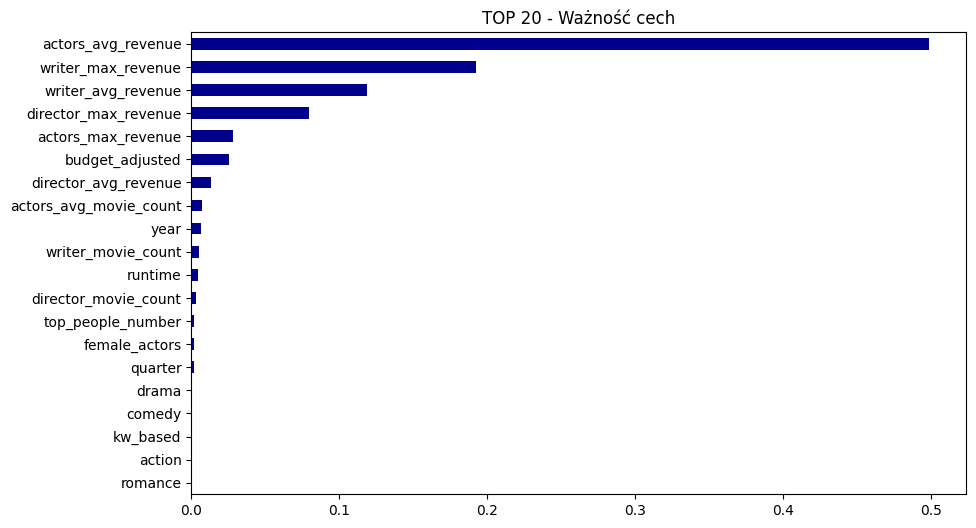

In [20]:
print("WYNIKI MODELU:")
print(f"R^2 Score: {r2:.4f}")
print(f"MAE:       ${mae:,.2f}")
print(f"RMSE:      ${rmse:,.2f}")
print(f"MAPE:      {mape*100:.2f}%")

importances = pd.Series(best_model_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='darkblue').invert_yaxis()
plt.title("TOP 20 - Ważność cech")
plt.show()

### Zlogarytmowanie danych i minimalizacja MAE

In [18]:
y_log = np.log1p(y)
X_log = X.copy()

X_log['budget_adjusted'] = np.log1p(X_log['budget_adjusted'])

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=123)

In [62]:
def objective(trial):

    param_grid = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
    }
    
    model = RandomForestRegressor(**param_grid, random_state=123, n_jobs=-1)
    
    # 3-krotna cross-walidacja minimalizująca MAE
    scores = cross_val_score(
        model, 
        X_train_log,  
        y_train_log, 
        cv=3, 
        scoring='neg_mean_absolute_error', 
        n_jobs=-1
    )
    
    return -scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30) 

print("\nNajlepsze parametry:", study.best_params)

[I 2026-04-17 21:12:23,676] A new study created in memory with name: no-name-534de6e2-e09c-4acf-9e07-ddef49a3a786
[I 2026-04-17 21:13:00,245] Trial 0 finished with value: 0.3958482522635 and parameters: {'n_estimators': 150, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.3958482522635.
[I 2026-04-17 21:13:12,607] Trial 1 finished with value: 0.390537575424895 and parameters: {'n_estimators': 100, 'max_depth': 25, 'min_samples_split': 19, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.390537575424895.
[I 2026-04-17 21:13:52,840] Trial 2 finished with value: 0.3907273253714055 and parameters: {'n_estimators': 650, 'max_depth': 25, 'min_samples_split': 19, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.390537575424895.
[I 2026-04-17 21:14:14,036] Trial 3 finished with value: 0.399526200526509 and parameters: {'n_estimators': 300, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.39053


Najlepsze parametry: {'n_estimators': 550, 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 3}


In [63]:
best_model_rf = RandomForestRegressor(**study.best_params, random_state=123, n_jobs=-1)
best_model_rf.fit(X_train_log, y_train_log)

# Predykcja na zbiorze testowym (wynik to logarytmy)
y_pred_log = best_model_rf.predict(X_test_log)

# Przywrócenie normalnej skali (odwrócenie logarytmu)
y_test_real = np.expm1(y_test_log) 
y_pred_real = np.expm1(y_pred_log)

# Obliczanie metryk na realnej skali dolarowej
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)
mape = mean_absolute_percentage_error(y_test_real, y_pred_real)


WYNIKI MODELU
R^2 Score: 0.8735
MAE:       $30,110,959.11
RMSE:      $67,724,544.76
MAPE:      246.51%


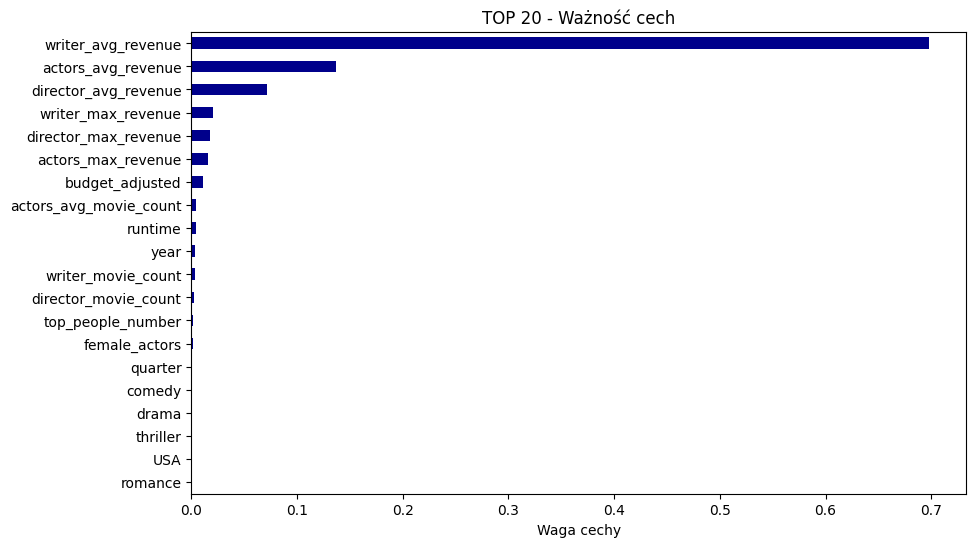

In [64]:
print("WYNIKI MODELU")
print(f"R^2 Score: {r2:.4f}")
print(f"MAE:       ${mae:,.2f}")
print(f"RMSE:      ${rmse:,.2f}")
print(f"MAPE:      {mape*100:.2f}%")

importances = pd.Series(best_model_rf.feature_importances_, index=X_log.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='darkblue').invert_yaxis()
plt.title("TOP 20 - Ważność cech")
plt.xlabel("Waga cechy")
plt.show()